In [1]:
from datetime import datetime

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score,
    log_loss, confusion_matrix
)
from sklearn.model_selection import train_test_split, StratifiedKFold
import optuna
import json

# MLflow — experiment tracking, parameter logging, model registry
import mlflow
import mlflow.xgboost
import mlflow.lightgbm

/Users/dan/Coding/Uni/HSLU/artificial_intelligence/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# MLflow Experiment Configuration
# ============================================================
# MLflow is an open-source platform for managing the end-to-end
# machine learning lifecycle. Here we configure it to:
#
# 1. Store tracking metadata (params, metrics) in a local SQLite
#    database and artifacts in a local ./mlruns directory.
#    A SQL backend is required for full MLflow UI functionality
#    (Overview tab, model registry, search, etc.).
# 2. Group every run under a single experiment named
#    "Customer_Churn_Prediction" so that different training
#    sessions are easy to compare in the MLflow UI.
#
# To browse logged experiments after running this notebook:
#    cd project && mlflow ui --port 5000
# Then open http://localhost:5000 in your browser.
# ============================================================

from pathlib import Path

_project_dir = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
_db_path = _project_dir / "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{_db_path}")

mlflow.set_experiment(f"Customer_Churn_Prediction")

print(f"MLflow Tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow Experiment   : Customer_Churn_Prediction")
print(f"MLflow Version      : {mlflow.__version__}")

MLflow Tracking URI : sqlite:////Users/dan/Coding/Uni/HSLU/artificial_intelligence/project/mlflow.db
MLflow Experiment   : Customer_Churn_Prediction
MLflow Version      : 3.10.0


In [4]:
train = pd.read_csv('../project/dataset/train.csv')
test = pd.read_csv('../project/dataset/test.csv')
test_sub = pd.read_csv('../project/dataset/sample_submission.csv')

In [5]:
train.shape

(594194, 21)

In [6]:
test.shape

(254655, 20)

In [7]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [9]:
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
train.duplicated().sum()

np.int64(0)

In [11]:
train = train.drop(columns = ['id'])
test_id = test['id']
test = test.drop(columns = ['id'])

### EDA

In [12]:
numaric_col = train.select_dtypes(exclude = ['object']).columns
object_col = train.select_dtypes(include = ['object']).columns
print('Numaric_col :',numaric_col)
print('Categorical_col :' , object_col)

Numaric_col : Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Categorical_col : Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [13]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


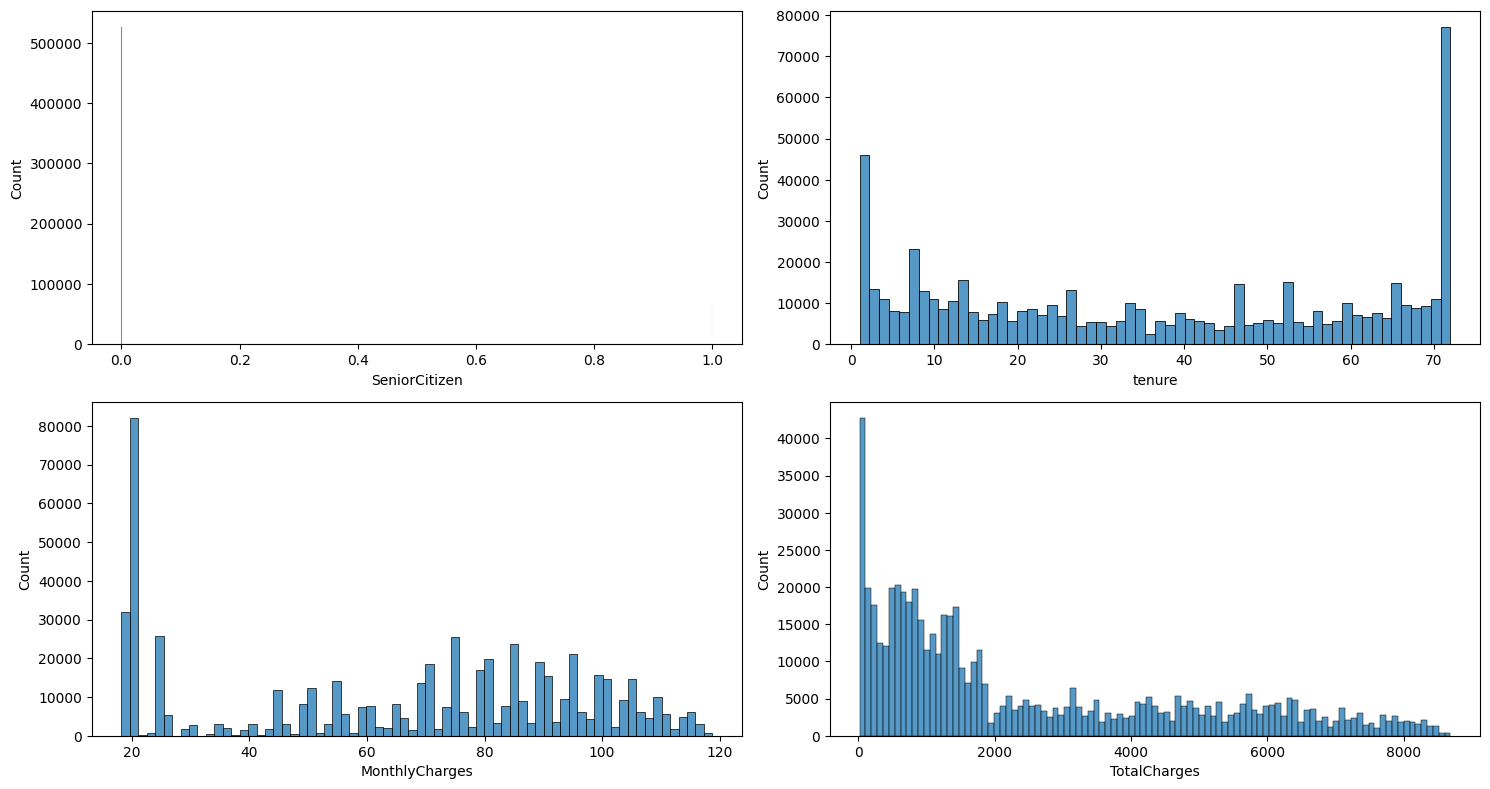

In [14]:
plt.figure(figsize = (15 , 8))
for i,col in enumerate(numaric_col):
    plt.subplot(2,2, i+1)
    sns.histplot(train[col])
plt.tight_layout()
plt.show()

In [15]:
for i,col in enumerate(numaric_col):
    print(col , ':' ,train[col].skew())

SeniorCitizen : 2.4275257022803975
tenure : 0.06305029865312908
MonthlyCharges : -0.2894857142399094
TotalCharges : 0.9091694109942958


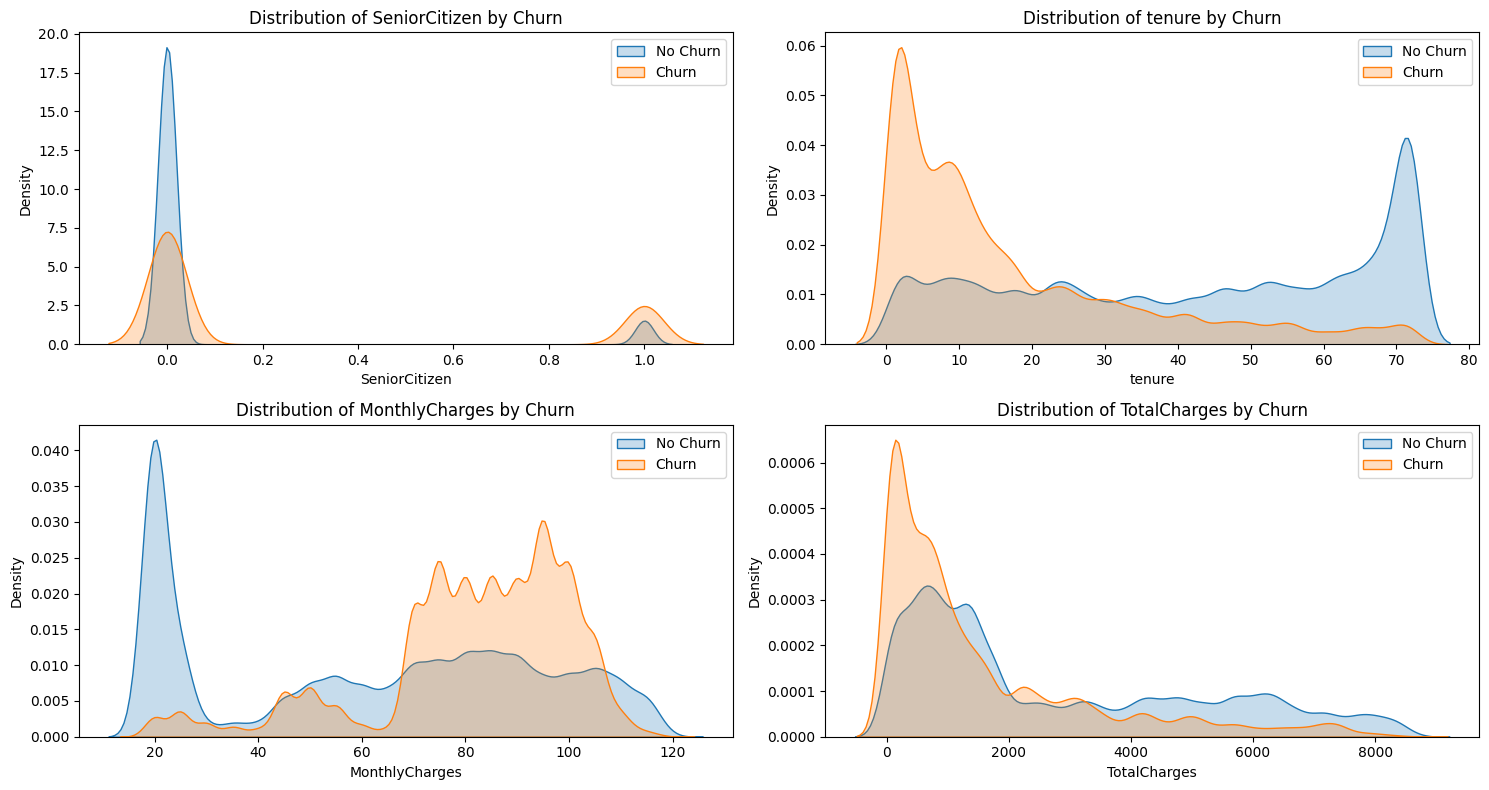

In [16]:
plt.figure(figsize=(15,8))
for i,col in enumerate(numaric_col):
    plt.subplot(2,2,i+1)
    sns.kdeplot(data=train[train["Churn"]=="No"], x=col, label="No Churn", fill=True)
    sns.kdeplot(data=train[train["Churn"]=="Yes"], x=col, label="Churn", fill=True)
    plt.legend()
    plt.title(f"Distribution of {col} by Churn")
plt.tight_layout()
plt.show()

In [17]:
object_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

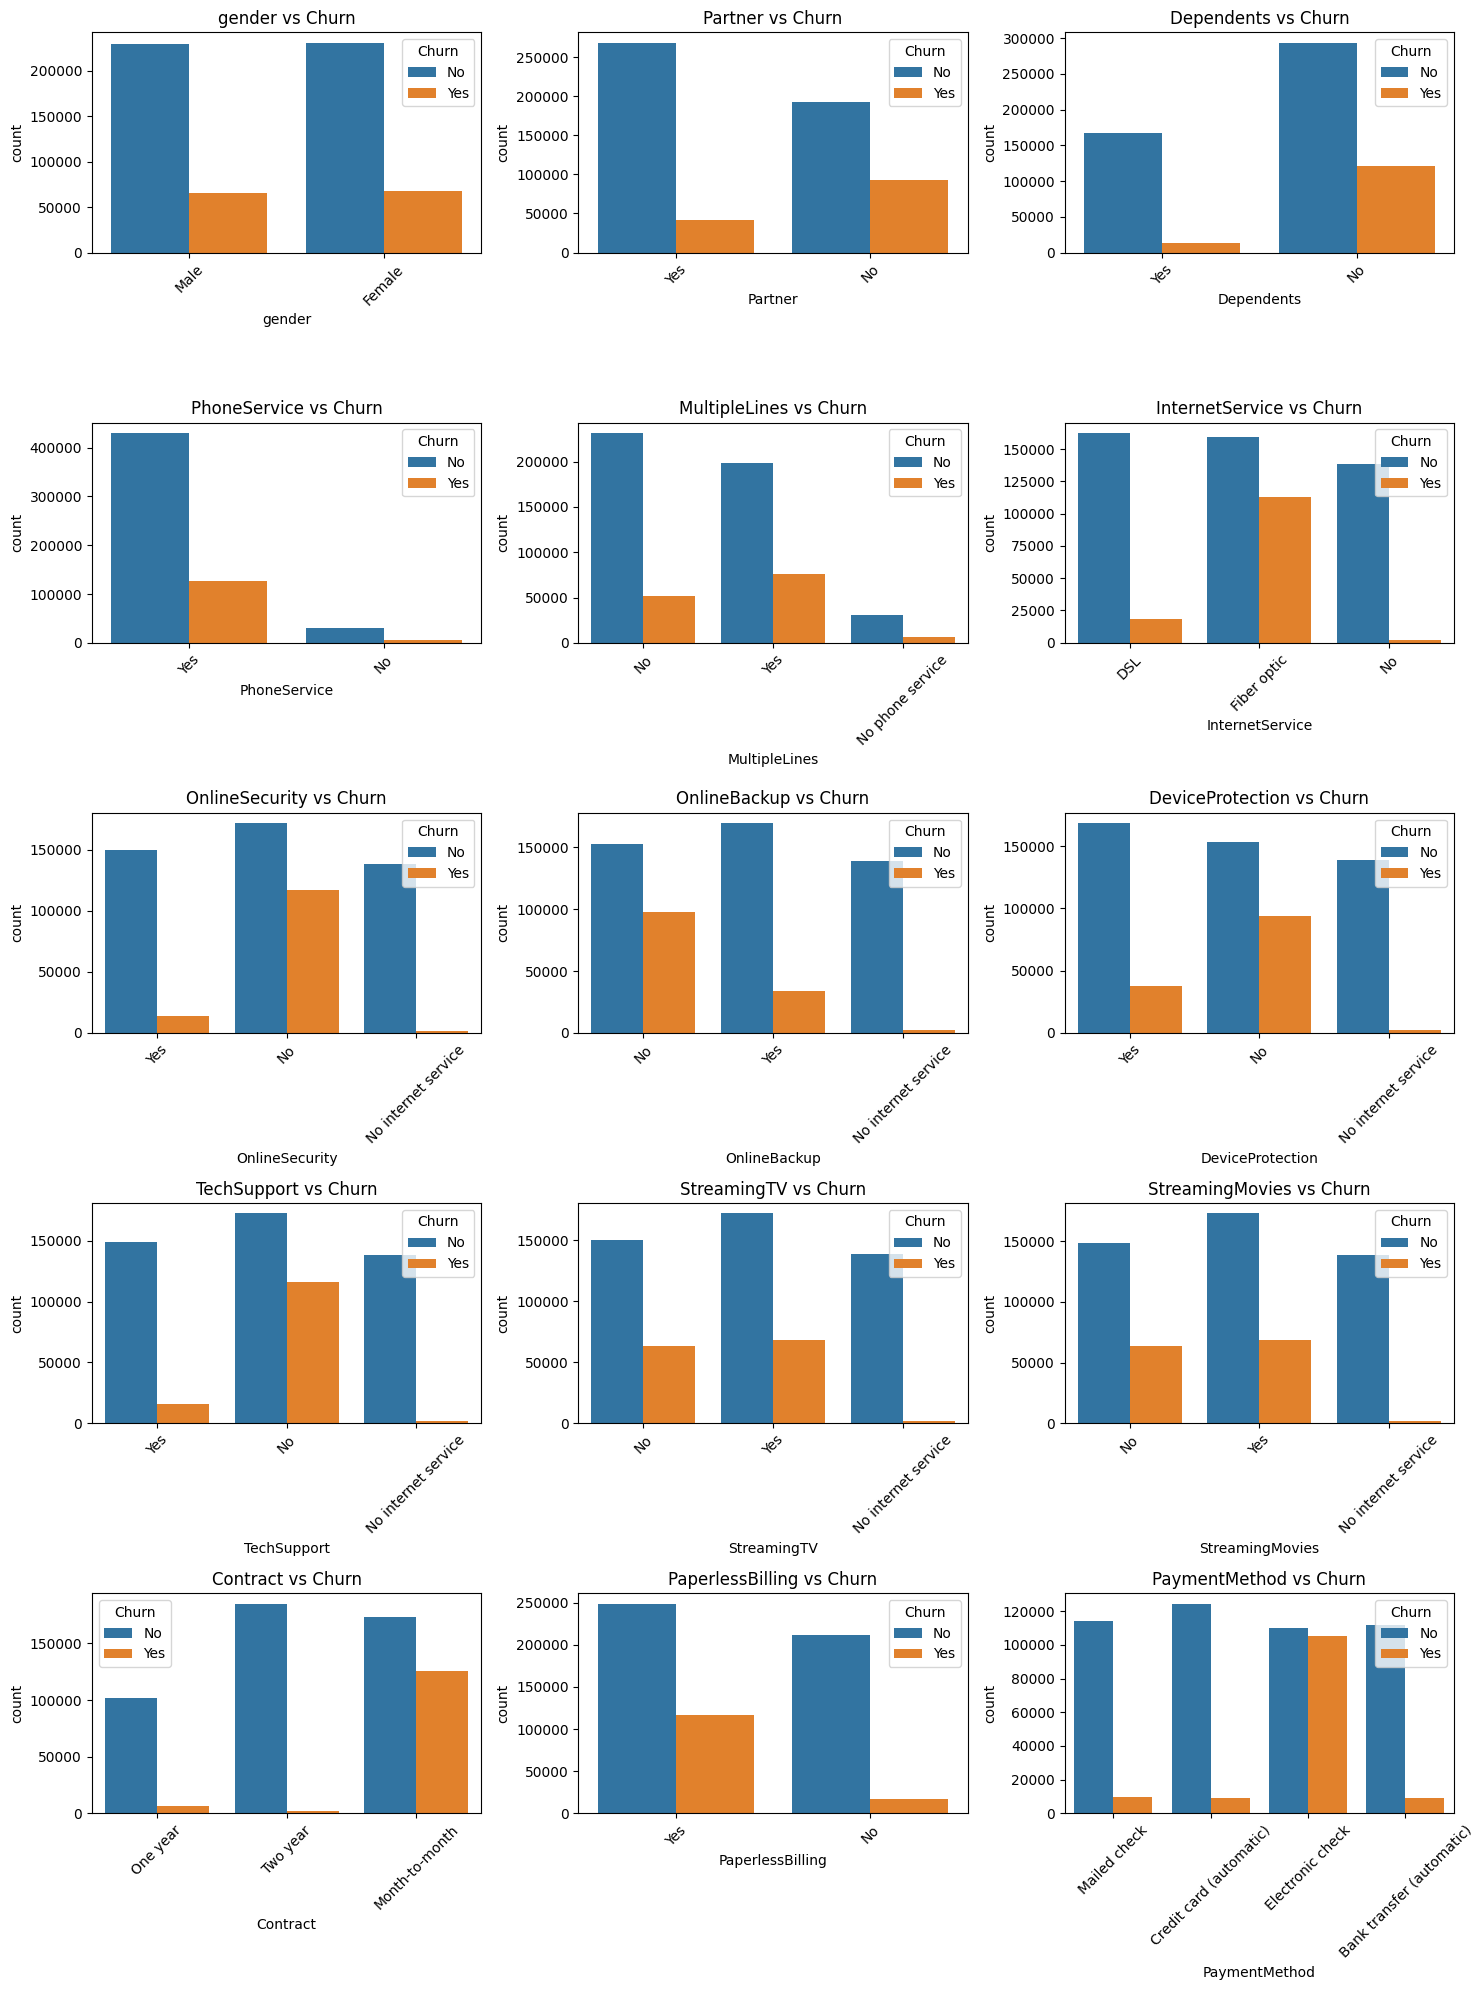

In [18]:
plt.figure(figsize=(15,20))
for i,col in enumerate(object_col):
    if col != 'Churn':
        plt.subplot(5,3,i+1)
        sns.countplot(data=train, x=col, hue="Churn")
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

In [19]:
train.sample()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
527902,Male,1,No,No,5,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.85,500.1,Yes


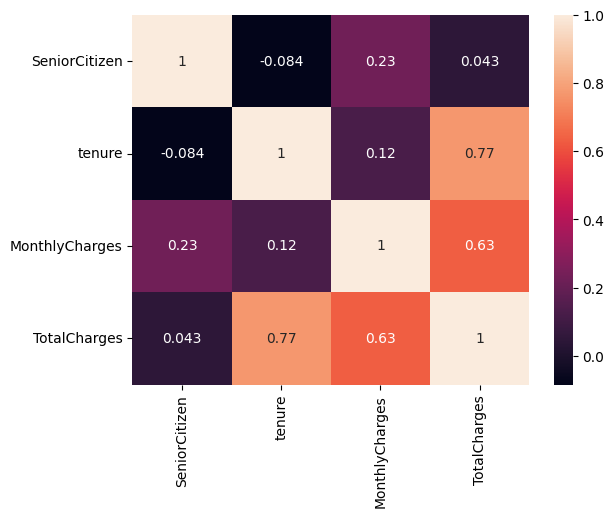

In [20]:
sns.heatmap(train[numaric_col].corr() , annot = True)
plt.show()

In [21]:
train.nunique()

gender                  2
SeniorCitizen           2
Partner                 2
Dependents              2
tenure                 72
PhoneService            2
MultipleLines           3
InternetService         3
OnlineSecurity          3
OnlineBackup            3
DeviceProtection        3
TechSupport             3
StreamingTV             3
StreamingMovies         3
Contract                3
PaperlessBilling        2
PaymentMethod           4
MonthlyCharges       1921
TotalCharges        31910
Churn                   2
dtype: int64

### Feature Engineering

In [22]:
def feature_eng(df):
    df["AvgMonthlyCharge"] = df["TotalCharges"] / (df["tenure"] + 1)
    services = [
        "PhoneService","MultipleLines","OnlineSecurity",
        "OnlineBackup","DeviceProtection","TechSupport",
        "StreamingTV","StreamingMovies"
    ]
    df["TotalServices"] = (df[services] == "Yes").sum(axis=1)
    return df

train = feature_eng(train)
test = feature_eng(test)

In [23]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

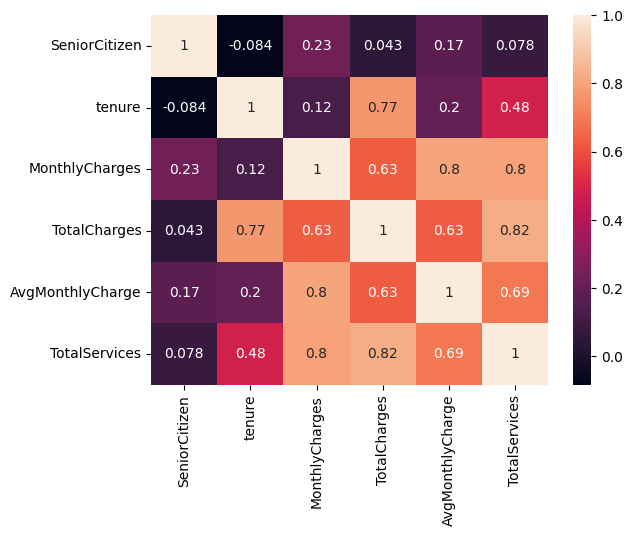

In [24]:
numaric_col = train.select_dtypes(exclude = ['object']).columns
sns.heatmap(train[numaric_col].corr() , annot = True)
plt.show()

In [25]:
object_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [26]:
train = pd.get_dummies(train , columns = ['MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract','PaymentMethod'] , drop_first = True , dtype = int)
test = pd.get_dummies(test , columns = ['MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract','PaymentMethod'] , drop_first = True , dtype = int)

In [27]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,Male,0,Yes,Yes,29,Yes,Yes,60.10,1653.85,No,...,1,0,0,0,0,1,0,0,0,1
1,Male,0,Yes,Yes,58,Yes,No,69.50,3778.20,No,...,1,0,1,0,0,0,1,1,0,0
2,Male,0,Yes,No,58,Yes,Yes,100.40,5841.35,No,...,0,0,1,0,1,0,0,0,1,0
3,Female,0,No,No,1,Yes,Yes,69.70,70.70,Yes,...,0,0,0,0,0,0,0,0,1,0
4,Female,0,No,No,1,Yes,Yes,70.45,70.45,Yes,...,0,0,0,0,0,0,0,0,1,0


In [28]:
# TODO: Use LabelEncoder for categorical features
def encoding(df):
    df['gender'] = df['gender'].map({'Male':1 , 'Female':0})
    df['Partner'] = df['Partner'].map({'Yes':1 , 'No':0})
    df['Dependents'] = df['Dependents'].map({'Yes':1 , 'No':0})
    df['PhoneService'] = df['PhoneService'].map({'Yes':1 , 'No':0})
    df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1 , 'No':0})
    return df
train = encoding(train)
test = encoding(test)

In [29]:
train = train.drop(columns = ['gender'])
test = test.drop(columns = ['gender'])

In [30]:
train['Churn'] = train['Churn'].map({'Yes':1 , 'No':0})

In [31]:
train.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,29,1,1,60.10,1653.85,0,55.128333,...,1,0,0,0,0,1,0,0,0,1
1,0,1,1,58,1,0,69.50,3778.20,0,64.037288,...,1,0,1,0,0,0,1,1,0,0
2,0,1,0,58,1,1,100.40,5841.35,0,99.005932,...,0,0,1,0,1,0,0,0,1,0
3,0,0,0,1,1,1,69.70,70.70,1,35.350000,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,1,1,1,70.45,70.45,1,35.225000,...,0,0,0,0,0,0,0,0,1,0


In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 32 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   SeniorCitizen                          594194 non-null  int64  
 1   Partner                                594194 non-null  int64  
 2   Dependents                             594194 non-null  int64  
 3   tenure                                 594194 non-null  int64  
 4   PhoneService                           594194 non-null  int64  
 5   PaperlessBilling                       594194 non-null  int64  
 6   MonthlyCharges                         594194 non-null  float64
 7   TotalCharges                           594194 non-null  float64
 8   Churn                                  594194 non-null  int64  
 9   AvgMonthlyCharge                       594194 non-null  float64
 10  TotalServices                          594194 non-null  

In [33]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 31 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   SeniorCitizen                          254655 non-null  int64  
 1   Partner                                254655 non-null  int64  
 2   Dependents                             254655 non-null  int64  
 3   tenure                                 254655 non-null  int64  
 4   PhoneService                           254655 non-null  int64  
 5   PaperlessBilling                       254655 non-null  int64  
 6   MonthlyCharges                         254655 non-null  float64
 7   TotalCharges                           254655 non-null  float64
 8   AvgMonthlyCharge                       254655 non-null  float64
 9   TotalServices                          254655 non-null  int64  
 10  MultipleLines_No phone service         254655 non-null  

### MultiModel Ensemble

In [34]:
X = train.drop(columns = ['Churn'])
y = train['Churn']

In [35]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

## Hyperparameter Tuning with Optuna

Optuna uses **TPE (Tree-structured Parzen Estimator)**, a Bayesian optimisation sampler that models the relationship between hyperparameters and the objective metric. Unlike grid search (exhaustive, exponential cost) or random search (no learning), TPE focuses subsequent trials on the most promising regions of the search space, converging faster with fewer evaluations.

**Strategy:**
- Each trial trains a model with 5-fold Stratified CV on the full training set (`X`, `y`) and returns the **mean ROC-AUC** — the same metric and CV scheme used in the final evaluation loop.
- Log-uniform sampling (`log=True`) is used for learning rate and regularisation terms because these parameters span orders of magnitude.
- Studies are persisted to an SQLite database so tuning can be resumed if interrupted.
- After both studies complete, the best parameters are extracted into `best_lgbm_params` and `best_xgb_params`.

In [36]:
# ============================================================
# Optuna Objective — LightGBM
# ============================================================
# The objective function is called once per trial.  Optuna's
# TPE sampler proposes a set of hyperparameters via the
# `trial.suggest_*` API; we train a LightGBM classifier with
# those params under 5-fold Stratified CV and return the mean
# ROC-AUC so Optuna can decide where to sample next.
# ============================================================

from sklearn.model_selection import cross_val_score

def objective_lgbm(trial: optuna.Trial) -> float:
    """Return mean 5-fold ROC-AUC for a LightGBM parameterisation."""

    params = {
        # Number of boosting rounds — more rounds can improve fit
        # but increase training time and risk of overfitting.
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),

        # Shrinkage applied to each tree's contribution.
        # Log-uniform because useful values span ~0.01–0.3.
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        # Maximum number of leaves per tree — controls model
        # complexity.  Larger values capture more interactions
        # but risk overfitting on noisy features.
        "num_leaves": trial.suggest_int("num_leaves", 10, 60),

        # Hard cap on tree depth (complements num_leaves).
        "max_depth": trial.suggest_int("max_depth", 3, 10),

        # Minimum samples required in a leaf — acts as a
        # regulariser by preventing very small, noisy leaves.
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),

        # Row subsampling ratio per tree — reduces variance.
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),

        # Column subsampling ratio per tree — decorrelates trees.
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),

        # L1 (Lasso) regularisation on leaf weights.
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),

        # L2 (Ridge) regularisation on leaf weights.
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model = LGBMClassifier(**params, verbosity=-1, random_state=42)

    # 5-fold Stratified CV — same scheme used in the final
    # evaluation loop so the tuning signal is consistent.
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)

    return scores.mean()

In [37]:
# ============================================================
# Optuna Objective — XGBoost
# ============================================================
# Same approach as the LightGBM objective above, adapted for
# XGBoost's parameter names and an additional `gamma` parameter
# (minimum loss reduction required to make a further partition).
# ============================================================

def objective_xgb(trial: optuna.Trial) -> float:
    """Return mean 5-fold ROC-AUC for an XGBoost parameterisation."""

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),

        # Row and column subsampling — same role as in LightGBM.
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),

        # Minimum loss reduction to create a new split.  Acts as
        # a conservative regulariser — higher values make the
        # algorithm more reluctant to add branches.
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),

        # L1 and L2 regularisation (same rationale as LightGBM).
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),

        # Fixed (non-tuned) parameters.
        "random_state": 42,
        "eval_metric": "auc",
    }

    model = XGBClassifier(**params, verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)

    return scores.mean()

In [38]:
# ============================================================
# Run Optuna Studies & Extract Best Parameters
# ============================================================
# Each study runs N_TRIALS trials.  Optuna's TPE sampler uses
# the results of earlier trials to build a probabilistic model
# of the objective landscape and proposes increasingly better
# candidates.  100 trials is a solid default — increase if you
# have compute budget, or decrease for a quick sanity check.
#
# SQLite storage lets you resume an interrupted study: just
# re-run this cell and Optuna picks up where it left off
# (load_if_exists=True).
#
# optuna.logging.set_verbosity(WARNING) silences per-trial
# stdout noise while the progress bar still provides feedback.
# ============================================================

# N_TRIALS = 100
N_TRIALS = 20

# Reduce Optuna's console noise to warnings only.
# The progress bar (show_progress_bar=True) is more informative.
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ---- LightGBM study ----
# `create_study` with SQLite storage makes the study resumable.
# direction="maximize" because higher ROC-AUC is better.
study_lgbm = optuna.create_study(
    direction="maximize",
    study_name="lgbm_tuning",
    storage="sqlite:///project/optuna_studies.db",
    load_if_exists=True,
)
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

print(f"LightGBM — best trial #{study_lgbm.best_trial.number}")
print(f"  Mean CV AUC : {study_lgbm.best_value:.6f}")
print(f"  Params      : {study_lgbm.best_params}")

# ---- XGBoost study ----
study_xgb = optuna.create_study(
    direction="maximize",
    study_name="xgb_tuning",
    storage="sqlite:///project/optuna_studies.db",
    load_if_exists=True,
)
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nXGBoost  — best trial #{study_xgb.best_trial.number}")
print(f"  Mean CV AUC : {study_xgb.best_value:.6f}")
print(f"  Params      : {study_xgb.best_params}")

# ---- Extract the winning hyperparameters ----
# best_params contains only the tuned keys; we add back the
# fixed parameters that XGBoost needs (random_state, eval_metric)
# so the downstream training cell works unchanged.
best_lgbm_params = study_lgbm.best_params
best_xgb_params = {
    **study_xgb.best_params,
    "random_state": 42,
    "eval_metric": "auc",
}

print("\n✓ best_lgbm_params and best_xgb_params are ready for training.")

Best trial: 25. Best value: 0.916781: 100%|██████████| 20/20 [14:34<00:00, 43.73s/it]


LightGBM — best trial #25
  Mean CV AUC : 0.916781
  Params      : {'n_estimators': 1639, 'learning_rate': 0.03574422401602494, 'num_leaves': 23, 'max_depth': 5, 'min_child_samples': 30, 'subsample': 0.5991571422558087, 'colsample_bytree': 0.4539367041287359, 'reg_alpha': 2.9209821253017614, 'reg_lambda': 0.040722022652391436}


Best trial: 16. Best value: 0.916742: 100%|██████████| 20/20 [08:47<00:00, 26.40s/it]


XGBoost  — best trial #16
  Mean CV AUC : 0.916742
  Params      : {'n_estimators': 1780, 'max_depth': 5, 'learning_rate': 0.037767289395755355, 'subsample': 0.7298636990387892, 'colsample_bytree': 0.5919286922450262, 'gamma': 0.2309197009778641, 'reg_alpha': 0.5664526542021853, 'reg_lambda': 1.6795582021868924}

✓ best_lgbm_params and best_xgb_params are ready for training.



  FOLD 1 / 5
  Train size: 475,355 | Val size: 118,839


2026/03/03 21:30:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 21:30:00 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/03 21:30:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  LightGBM — AUC: 0.916470 | Acc: 0.862023 | F1: 0.677002


2026/03/03 21:30:17 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  XGBoost  — AUC: 0.916419 | Acc: 0.861628 | F1: 0.676108

  FOLD 2 / 5
  Train size: 475,355 | Val size: 118,839


...

  XGBoost  — AUC: 0.917916 | Acc: 0.862814 | F1: 0.677685

  FOLD 5 / 5
  Train size: 475,356 | Val size: 118,838


2026/03/03 21:32:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/03 21:32:05 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/03 21:32:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  LightGBM — AUC: 0.915242 | Acc: 0.861484 | F1: 0.676060


2026/03/03 21:32:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  XGBoost  — AUC: 0.915166 | Acc: 0.861433 | F1: 0.676261


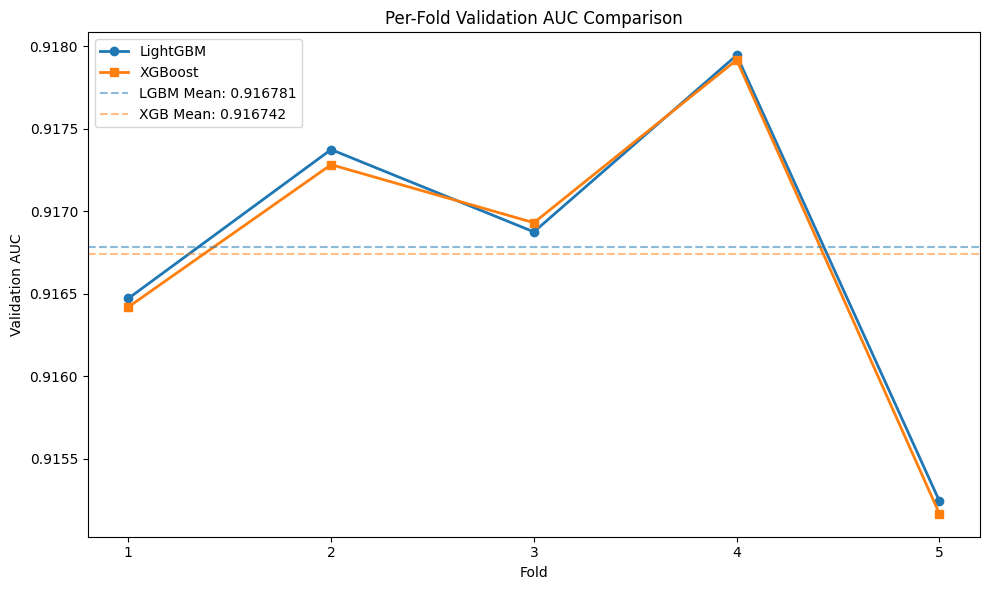


  CV Training Completed
  LightGBM — Mean AUC: 0.916781 (+/- 0.000914)
  XGBoost  — Mean AUC: 0.916742 (+/- 0.000927)


In [39]:
# ============================================================
# Stratified K-Fold Cross-Validation with MLflow Tracking
# ============================================================
# This cell is the core of the training pipeline. It performs
# 5-fold stratified cross-validation for both LightGBM and
# XGBoost models. Every aspect is tracked via MLflow:
#
# Parent run  — holds dataset metadata, all hyperparameters,
#               aggregated CV metrics, and comparison plots.
# Child runs  — one per model per fold; each stores its own
#               validation metrics, feature-importance chart,
#               and serialised model artifact.
#
# The validation fold (val_idx) — which the original code
# ignored — is now used to compute AUC, accuracy, precision,
# recall, F1, and log-loss on held-out data every fold.
# ============================================================

N_SPLITS = 5
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Accumulators: averaged test-set predictions (one per model)
lgb_test_preds = np.zeros(len(test))
xgb_test_preds = np.zeros(len(test))

# Accumulators: per-fold validation metrics for later aggregation
lgb_val_aucs, xgb_val_aucs = [], []
lgb_val_accs, xgb_val_accs = [], []
lgb_val_f1s, xgb_val_f1s = [], []
lgb_val_precisions, xgb_val_precisions = [], []
lgb_val_recalls, xgb_val_recalls = [], []
lgb_val_logloss, xgb_val_logloss = [], []

# ---- Safety: end any lingering active run from a prior cell ----
# In notebooks it is common to re-run cells. Calling end_run()
# first prevents accidentally nesting under a stale parent.
mlflow.end_run()

# ---- Start the top-level (parent) MLflow run ----
# This run is the umbrella container for the whole experiment.
# We deliberately open it *without* a context manager so that
# subsequent cells (ensemble, submission) can still log into it.
mlflow.start_run(run_name="Customer_Churn_Ensemble")

# -- Log dataset metadata --
# Recording shapes, feature count, and class balance makes
# every run self-documenting and fully reproducible.
mlflow.log_param("dataset_train_rows", X.shape[0])
mlflow.log_param("dataset_train_cols", X.shape[1])
mlflow.log_param("dataset_test_rows", len(test))
mlflow.log_param("target_positive_rate", round(float(y.mean()), 4))
mlflow.log_param("cv_n_splits", N_SPLITS)
mlflow.log_param("cv_random_state", RANDOM_STATE)

# -- Experiment tags for easy filtering in the MLflow UI --
mlflow.set_tag("task_type", "binary_classification")
mlflow.set_tag("ensemble_method", "simple_average")
mlflow.set_tag("models_used", "LightGBM, XGBoost")
mlflow.set_tag("target_column", "Churn")

# -- Log hyperparameters for both models to the parent run --
# Prefixing each key with the model name avoids collisions and
# makes the parameter table immediately interpretable.
for k, v in best_lgbm_params.items():
    mlflow.log_param(f"lgbm_{k}", v)
for k, v in best_xgb_params.items():
    mlflow.log_param(f"xgb_{k}", v)

# -- Persist the ordered feature list as an artifact --
# Stored as JSON so it can be loaded programmatically later
# when reproducing or serving the model.
mlflow.log_text(json.dumps(list(X.columns), indent=2), "feature_list.json")

# ============================================================
# Cross-Validation Loop
# ============================================================
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold + 1} / {N_SPLITS}")
    print(f"  Train size: {len(train_idx):,} | Val size: {len(val_idx):,}")
    print(f"{'='*60}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = X.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    # --------------------------------------------------------
    # LightGBM — nested child run
    # --------------------------------------------------------
    # Each child run is fully self-contained so it can be
    # inspected independently in the MLflow UI.
    with mlflow.start_run(run_name=f"LightGBM_Fold_{fold+1}", nested=True):

        # Log identifying information for this child run
        mlflow.log_param("model_type", "LightGBM")
        mlflow.log_param("fold", fold + 1)
        mlflow.log_param("train_fold_size", len(train_idx))
        mlflow.log_param("val_fold_size", len(val_idx))

        # Duplicate the hyperparameters inside the child run so
        # each run is independently interpretable.
        mlflow.log_params({f"lgbm_{k}": v for k, v in best_lgbm_params.items()})

        # Train the model on this fold's training split
        lgb_model = LGBMClassifier(
            **best_lgbm_params,
            objective="binary",
            random_state=RANDOM_STATE,
            verbosity=-1
        )
        lgb_model.fit(X_train_fold, y_train_fold)

        # -- Validation predictions --
        # predict_proba[:, 1] gives the probability of the
        # positive class (Churn = 1).
        lgb_val_proba = lgb_model.predict_proba(X_val_fold)[:, 1]
        lgb_val_pred  = lgb_model.predict(X_val_fold)

        # -- Compute a full suite of validation metrics --
        fold_lgb_auc  = roc_auc_score(y_val_fold, lgb_val_proba)
        fold_lgb_acc  = accuracy_score(y_val_fold, lgb_val_pred)
        fold_lgb_prec = precision_score(y_val_fold, lgb_val_pred)
        fold_lgb_rec  = recall_score(y_val_fold, lgb_val_pred)
        fold_lgb_f1   = f1_score(y_val_fold, lgb_val_pred)
        fold_lgb_ll   = log_loss(y_val_fold, lgb_val_proba)

        # Log every metric — these appear as columns in the
        # MLflow comparison table and can be plotted over time.
        mlflow.log_metric("val_auc",       fold_lgb_auc)
        mlflow.log_metric("val_accuracy",  fold_lgb_acc)
        mlflow.log_metric("val_precision", fold_lgb_prec)
        mlflow.log_metric("val_recall",    fold_lgb_rec)
        mlflow.log_metric("val_f1",        fold_lgb_f1)
        mlflow.log_metric("val_log_loss",  fold_lgb_ll)

        # -- Feature importance chart --
        # Plotting the top-15 features per fold helps verify
        # that feature rankings are stable across folds.
        feat_imp = pd.DataFrame({
            "feature": X.columns,
            "importance": lgb_model.feature_importances_
        }).sort_values("importance", ascending=False)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.barplot(data=feat_imp.head(15), x="importance", y="feature", ax=ax)
        ax.set_title(f"LightGBM Feature Importance — Fold {fold+1}")
        plt.tight_layout()
        mlflow.log_figure(fig, f"lgbm_feature_importance_fold_{fold+1}.png")
        plt.close(fig)

        # -- Confusion matrix heatmap --
        # Logged as an image artifact so you can visually
        # inspect TP/FP/TN/FN counts for each fold.
        cm = confusion_matrix(y_val_fold, lgb_val_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["No Churn", "Churn"],
                    yticklabels=["No Churn", "Churn"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"LightGBM Confusion Matrix — Fold {fold+1}")
        plt.tight_layout()
        mlflow.log_figure(fig, f"lgbm_confusion_matrix_fold_{fold+1}.png")
        plt.close(fig)

        # -- Serialise the trained model as an MLflow artifact --
        # This allows exact reproduction: load it later via
        # mlflow.lightgbm.load_model(model_uri).
        mlflow.lightgbm.log_model(lgb_model, artifact_path=f"lgbm_model_fold_{fold+1}")

        # Collect fold metrics for aggregation in the parent run
        lgb_val_aucs.append(fold_lgb_auc)
        lgb_val_accs.append(fold_lgb_acc)
        lgb_val_f1s.append(fold_lgb_f1)
        lgb_val_precisions.append(fold_lgb_prec)
        lgb_val_recalls.append(fold_lgb_rec)
        lgb_val_logloss.append(fold_lgb_ll)

        print(f"  LightGBM — AUC: {fold_lgb_auc:.6f} | "
              f"Acc: {fold_lgb_acc:.6f} | F1: {fold_lgb_f1:.6f}")

    # Accumulate averaged test predictions (outside the child run
    # context so the prediction itself isn't logged as a metric).
    lgb_fold_test_pred = lgb_model.predict_proba(test)[:, 1]
    lgb_test_preds += lgb_fold_test_pred / N_SPLITS

    # --------------------------------------------------------
    # XGBoost — nested child run
    # --------------------------------------------------------
    with mlflow.start_run(run_name=f"XGBoost_Fold_{fold+1}", nested=True):

        mlflow.log_param("model_type", "XGBoost")
        mlflow.log_param("fold", fold + 1)
        mlflow.log_param("train_fold_size", len(train_idx))
        mlflow.log_param("val_fold_size", len(val_idx))

        mlflow.log_params({f"xgb_{k}": v for k, v in best_xgb_params.items()})

        xgb_model = XGBClassifier(**best_xgb_params)
        xgb_model.fit(X_train_fold, y_train_fold)

        xgb_val_proba = xgb_model.predict_proba(X_val_fold)[:, 1]
        xgb_val_pred  = xgb_model.predict(X_val_fold)

        fold_xgb_auc  = roc_auc_score(y_val_fold, xgb_val_proba)
        fold_xgb_acc  = accuracy_score(y_val_fold, xgb_val_pred)
        fold_xgb_prec = precision_score(y_val_fold, xgb_val_pred)
        fold_xgb_rec  = recall_score(y_val_fold, xgb_val_pred)
        fold_xgb_f1   = f1_score(y_val_fold, xgb_val_pred)
        fold_xgb_ll   = log_loss(y_val_fold, xgb_val_proba)

        mlflow.log_metric("val_auc",       fold_xgb_auc)
        mlflow.log_metric("val_accuracy",  fold_xgb_acc)
        mlflow.log_metric("val_precision", fold_xgb_prec)
        mlflow.log_metric("val_recall",    fold_xgb_rec)
        mlflow.log_metric("val_f1",        fold_xgb_f1)
        mlflow.log_metric("val_log_loss",  fold_xgb_ll)

        feat_imp_xgb = pd.DataFrame({
            "feature": X.columns,
            "importance": xgb_model.feature_importances_
        }).sort_values("importance", ascending=False)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.barplot(data=feat_imp_xgb.head(15), x="importance", y="feature", ax=ax)
        ax.set_title(f"XGBoost Feature Importance — Fold {fold+1}")
        plt.tight_layout()
        mlflow.log_figure(fig, f"xgb_feature_importance_fold_{fold+1}.png")
        plt.close(fig)

        cm_xgb = confusion_matrix(y_val_fold, xgb_val_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges", ax=ax,
                    xticklabels=["No Churn", "Churn"],
                    yticklabels=["No Churn", "Churn"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"XGBoost Confusion Matrix — Fold {fold+1}")
        plt.tight_layout()
        mlflow.log_figure(fig, f"xgb_confusion_matrix_fold_{fold+1}.png")
        plt.close(fig)

        mlflow.xgboost.log_model(xgb_model, name=f"xgb_model_fold_{fold+1}")

        xgb_val_aucs.append(fold_xgb_auc)
        xgb_val_accs.append(fold_xgb_acc)
        xgb_val_f1s.append(fold_xgb_f1)
        xgb_val_precisions.append(fold_xgb_prec)
        xgb_val_recalls.append(fold_xgb_rec)
        xgb_val_logloss.append(fold_xgb_ll)

        print(f"  XGBoost  — AUC: {fold_xgb_auc:.6f} | "
              f"Acc: {fold_xgb_acc:.6f} | F1: {fold_xgb_f1:.6f}")

    xgb_fold_test_pred = xgb_model.predict_proba(test)[:, 1]
    xgb_test_preds += xgb_fold_test_pred / N_SPLITS

# ============================================================
# Log Aggregated CV Metrics to the Parent Run
# ============================================================
# Summary statistics (mean ± std) across all folds give a quick
# single-number assessment of each model's generalisation ability.

mlflow.log_metric("lgbm_mean_cv_auc",       np.mean(lgb_val_aucs))
mlflow.log_metric("lgbm_std_cv_auc",        np.std(lgb_val_aucs))
mlflow.log_metric("lgbm_mean_cv_accuracy",  np.mean(lgb_val_accs))
mlflow.log_metric("lgbm_mean_cv_precision", np.mean(lgb_val_precisions))
mlflow.log_metric("lgbm_mean_cv_recall",    np.mean(lgb_val_recalls))
mlflow.log_metric("lgbm_mean_cv_f1",        np.mean(lgb_val_f1s))
mlflow.log_metric("lgbm_mean_cv_log_loss",  np.mean(lgb_val_logloss))

mlflow.log_metric("xgb_mean_cv_auc",       np.mean(xgb_val_aucs))
mlflow.log_metric("xgb_std_cv_auc",        np.std(xgb_val_aucs))
mlflow.log_metric("xgb_mean_cv_accuracy",  np.mean(xgb_val_accs))
mlflow.log_metric("xgb_mean_cv_precision", np.mean(xgb_val_precisions))
mlflow.log_metric("xgb_mean_cv_recall",    np.mean(xgb_val_recalls))
mlflow.log_metric("xgb_mean_cv_f1",        np.mean(xgb_val_f1s))
mlflow.log_metric("xgb_mean_cv_log_loss",  np.mean(xgb_val_logloss))

# -- Per-fold AUC comparison chart --
# Visualises whether the two models track each other across
# folds and highlights any fold with anomalously low AUC.
fig, ax = plt.subplots(figsize=(10, 6))
fold_numbers = list(range(1, N_SPLITS + 1))
ax.plot(fold_numbers, lgb_val_aucs, marker="o", label="LightGBM", linewidth=2)
ax.plot(fold_numbers, xgb_val_aucs, marker="s", label="XGBoost", linewidth=2)
ax.axhline(np.mean(lgb_val_aucs), ls="--", color="tab:blue",   alpha=0.5,
           label=f"LGBM Mean: {np.mean(lgb_val_aucs):.6f}")
ax.axhline(np.mean(xgb_val_aucs), ls="--", color="tab:orange", alpha=0.5,
           label=f"XGB Mean: {np.mean(xgb_val_aucs):.6f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Validation AUC")
ax.set_title("Per-Fold Validation AUC Comparison")
ax.set_xticks(fold_numbers)
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig, "cv_auc_comparison.png")
plt.show()

# -- Per-fold metrics comparison table (logged as CSV artifact) --
metrics_df = pd.DataFrame({
    "fold": fold_numbers,
    "lgbm_auc": lgb_val_aucs, "xgb_auc": xgb_val_aucs,
    "lgbm_acc": lgb_val_accs, "xgb_acc": xgb_val_accs,
    "lgbm_f1":  lgb_val_f1s,  "xgb_f1":  xgb_val_f1s,
})
mlflow.log_text(metrics_df.to_csv(index=False), "cv_fold_metrics.csv")

print(f"\n{'='*60}")
print("  CV Training Completed")
print(f"{'='*60}")
print(f"  LightGBM — Mean AUC: {np.mean(lgb_val_aucs):.6f} "
      f"(+/- {np.std(lgb_val_aucs):.6f})")
print(f"  XGBoost  — Mean AUC: {np.mean(xgb_val_aucs):.6f} "
      f"(+/- {np.std(xgb_val_aucs):.6f})")
print(f"{'='*60}")

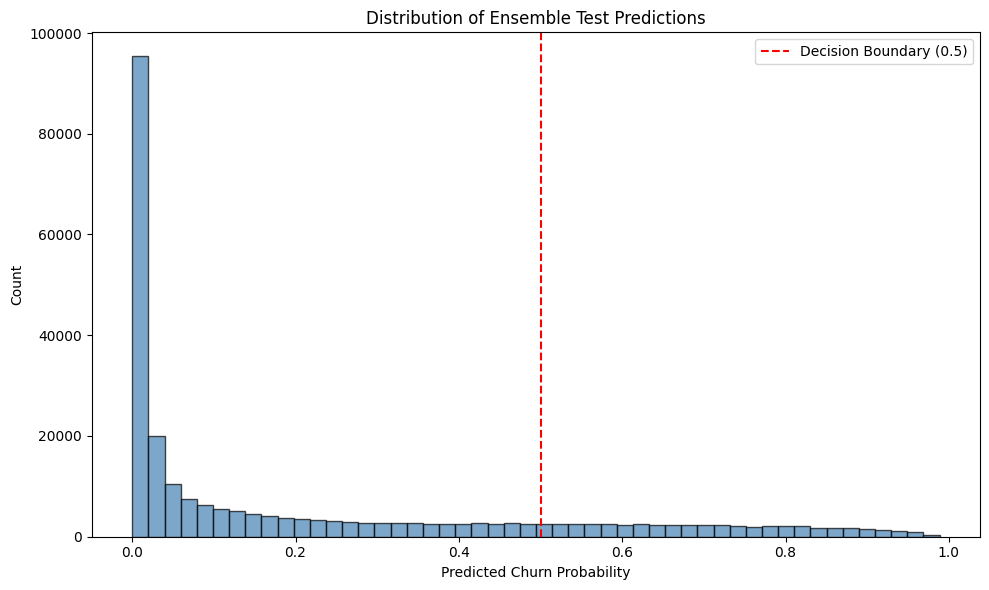

Ensemble prediction statistics:
  Mean:   0.218195
  Std:    0.276128
  Median: 0.063102
  Min:    0.000110
  Max:    0.988640


In [40]:
# ============================================================
# Ensemble: Average LightGBM and XGBoost Predictions
# ============================================================
# Simple averaging is one of the most robust ensemble methods.
# Each model's per-fold-averaged test probabilities are blended
# with equal weight (0.5 / 0.5). This typically reduces
# variance and improves out-of-sample performance compared to
# relying on a single model.
# ============================================================

final_test_preds = (lgb_test_preds + xgb_test_preds) / 2

# -- Log ensemble prediction statistics to the parent run --
# Tracking the distribution of predicted probabilities helps
# detect anomalies (e.g., all zeros) and gives a quick sense
# of predicted churn prevalence on the test set.
mlflow.log_metric("ensemble_pred_mean",   float(np.mean(final_test_preds)))
mlflow.log_metric("ensemble_pred_std",    float(np.std(final_test_preds)))
mlflow.log_metric("ensemble_pred_median", float(np.median(final_test_preds)))
mlflow.log_metric("ensemble_pred_min",    float(np.min(final_test_preds)))
mlflow.log_metric("ensemble_pred_max",    float(np.max(final_test_preds)))

# -- Histogram of ensemble predictions --
# A healthy distribution should show a clear separation between
# low-churn and high-churn probability customers.
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(final_test_preds, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
ax.set_xlabel("Predicted Churn Probability")
ax.set_ylabel("Count")
ax.set_title("Distribution of Ensemble Test Predictions")
ax.axvline(0.5, color="red", ls="--", linewidth=1.5, label="Decision Boundary (0.5)")
ax.legend()
plt.tight_layout()
mlflow.log_figure(fig, "ensemble_prediction_distribution.png")
plt.show()

print(f"Ensemble prediction statistics:")
print(f"  Mean:   {np.mean(final_test_preds):.6f}")
print(f"  Std:    {np.std(final_test_preds):.6f}")
print(f"  Median: {np.median(final_test_preds):.6f}")
print(f"  Min:    {np.min(final_test_preds):.6f}")
print(f"  Max:    {np.max(final_test_preds):.6f}")

In [41]:
submission_df = pd.DataFrame({'id':test_id , 'Churn':final_test_preds})
submission_df.head()

,id,Churn
0,594194,0.066000
1,594195,0.000557
2,594196,0.109216
3,594197,0.003320
4,594198,0.517874


In [42]:
# ============================================================
# Save Submission & Log as MLflow Artifact
# ============================================================
# The submission CSV is written to disk *and* logged as an
# MLflow artifact. This means you can retrieve it later from
# the MLflow UI or API (mlflow.artifacts.download_artifacts)
# without needing access to the original working directory.
# ============================================================

submission_df.to_csv('submission.csv', index=False)

# Log the submission file as an artifact of the parent run
mlflow.log_artifact("submission.csv")

print("Submission saved to 'submission.csv' and logged as MLflow artifact.")

Submission saved to 'submission.csv' and logged as MLflow artifact.


In [43]:
# ============================================================
# Finalise the MLflow Parent Run
# ============================================================
# Calling end_run() flushes all buffered data to the tracking
# store and marks the run as FINISHED. After this cell you can
# start the MLflow UI to explore every logged parameter, metric,
# artifact, and model:
#
#   mlflow ui --port 5000
#
# Then open http://localhost:5000 in your browser.
#
# What was logged (summary):
#  Parent run — "Customer_Churn_Ensemble"
#   ├── Parameters  : dataset shape, target rate, CV config,
#   │                  all LightGBM & XGBoost hyperparams
#   ├── Metrics     : mean/std CV AUC, accuracy, precision,
#   │                  recall, F1, log-loss (per model);
#   │                  ensemble prediction statistics
#   ├── Tags        : task type, ensemble method, model names
#   ├── Artifacts   : feature_list.json, cv_auc_comparison.png,
#   │                  cv_fold_metrics.csv,
#   │                  ensemble_prediction_distribution.png,
#   │                  submission.csv
#   └── Child runs (10 total = 2 models × 5 folds)
#        ├── Parameters  : model type, fold number, fold sizes,
#        │                  model-specific hyperparams
#        ├── Metrics     : val AUC, accuracy, precision, recall,
#        │                  F1, log-loss
#        ├── Artifacts   : feature importance plot,
#        │                  confusion matrix plot,
#        │                  serialised model artifact
#        └── (one child run per model per fold)
# ============================================================

# Retrieve the run ID before ending so we can print it
run_id = mlflow.active_run().info.run_id

mlflow.end_run()

print("=" * 60)
print("  MLflow run completed successfully!")
print("=" * 60)
print(f"  Run ID : {run_id}")
print(f"  To view : mlflow ui --port 5000")
print(f"  URL     : http://localhost:5000")
print("=" * 60)

  MLflow run completed successfully!
  Run ID : e30ceea6fd1b451b9c18efb9db1f9e94
  To view : mlflow ui --port 5000
  URL     : http://localhost:5000
